In [1]:
import os
import email
import pandas as pd
# Loading in the files of spam
def parse_eml_folder(folder_path):
    records = []
    for filename in sorted(os.listdir(folder_path)):
        if not filename.endswith('.eml'):
            continue
        with open(os.path.join(folder_path, filename), 'r', errors='ignore') as f:
            msg = email.message_from_file(f)
        
        body = ''
        if msg.is_multipart():
            for part in msg.walk():
                if part.get_content_type() == 'text/plain':
                    body = part.get_payload(decode=True).decode(errors='ignore')
                    break
        else:
            body = msg.get_payload(decode=True).decode(errors='ignore')

        records.append({
            'filename':    filename,
            'subject':     msg.get('Subject', ''),
            'sender':      msg.get('From', ''),
            'body':        body,
            'spam_status': msg.get('X-Spam-Status', '')
        })
    return pd.DataFrame(records)

# Point these at wherever your Downloads folder is
train_df = parse_eml_folder(os.path.expanduser('~/Downloads/TRAINING'))
test_df  = parse_eml_folder(os.path.expanduser('~/Downloads/TESTING'))

# Create binary label: 1 = spam, 0 = ham
train_df['label'] = train_df['spam_status'].str.startswith('Yes').astype(int)
test_df['label']  = test_df['spam_status'].str.startswith('Yes').astype(int)

print(train_df.shape, test_df.shape)
train_df.head()

(4327, 6) (4292, 6)


,filename,subject,sender,body,spam_status,label
0,TRAIN_00000.eml,One of a kind Money maker! Try it for free!,"""Ben Green"" <bengreen@mindupmerchants.com>",,,0
1,TRAIN_00001.eml,link to my webcam you wanted,Veronica Styles <lkqyvstyles@site-personals.com>,Wanna see sexually curious teens playing with ...,,0
2,TRAIN_00002.eml,Re: How to manage multiple Internet connections?,Andrei Popescu <andreimpopescu@csmining.org>,"On Sat,15.May.10, 16:47:07, Merciadri Luca wro...",,0
3,TRAIN_00003.eml,[SPAM] Give her 3 hour rodeo,"""Bel Barlow"" <hqp@imatiq.com>","Enhance your desire, pleasure and performance!...",,0
4,TRAIN_00004.eml,Best Price on the netf5f8m1,suddenlysusan@Stoolmail.zzn.com (),"(suddenlysusan@Stoolmail.zzn.com) on Tuesday,...",,0


In [13]:
print(train_df.describe())
print(f"Dimensions (rows, columns):  {train_df.shape}")

             label
count  4327.000000
mean      0.001387
std       0.037216
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       1.000000
Dimensions (rows, columns):  (4327, 6)


In [14]:
print(train_df.isnull().sum()) # No missing values

filename       0
subject        0
sender         0
body           0
spam_status    0
label          0
dtype: int64


In [17]:
train_df['label'].value_counts() # 4321 not spam, 6 spam?

label
0    4321
1       6
Name: count, dtype: int64

In [20]:
test_df['label'].value_counts() # 4288 not-spam and 4 spam?

label
0    4288
1       4
Name: count, dtype: int64

In [28]:
# Load the label file
labels = pd.read_csv(os.path.expanduser('~/Downloads/SPAMTrain.label'), 
                     header=None, names=['label'])
print(labels['label'].value_counts())
print(len(labels))

label
0 TRAIN_00000.eml    1
0 TRAIN_02890.eml    1
1 TRAIN_02876.eml    1
1 TRAIN_02877.eml    1
1 TRAIN_02878.eml    1
                    ..
0 TRAIN_01448.eml    1
0 TRAIN_01449.eml    1
1 TRAIN_01450.eml    1
1 TRAIN_01451.eml    1
0 TRAIN_04326.eml    1
Name: count, Length: 4327, dtype: int64
4327


In [29]:
# Sort train_df by filename to ensure order matches labels file
train_df = train_df.sort_values('filename').reset_index(drop=True)

# Assign labels
train_df['label'] = labels['label'].values
print(train_df['label'].value_counts())

label
0 TRAIN_00000.eml    1
0 TRAIN_02890.eml    1
1 TRAIN_02876.eml    1
1 TRAIN_02877.eml    1
1 TRAIN_02878.eml    1
                    ..
0 TRAIN_01448.eml    1
0 TRAIN_01449.eml    1
1 TRAIN_01450.eml    1
1 TRAIN_01451.eml    1
0 TRAIN_04326.eml    1
Name: count, Length: 4327, dtype: int64


In [31]:
train_df.head()

,filename,subject,sender,body,spam_status,label
0,TRAIN_00000.eml,One of a kind Money maker! Try it for free!,"""Ben Green"" <bengreen@mindupmerchants.com>",,,0 TRAIN_00000.eml
1,TRAIN_00001.eml,link to my webcam you wanted,Veronica Styles <lkqyvstyles@site-personals.com>,Wanna see sexually curious teens playing with ...,,0 TRAIN_00001.eml
2,TRAIN_00002.eml,Re: How to manage multiple Internet connections?,Andrei Popescu <andreimpopescu@csmining.org>,"On Sat,15.May.10, 16:47:07, Merciadri Luca wro...",,1 TRAIN_00002.eml
3,TRAIN_00003.eml,[SPAM] Give her 3 hour rodeo,"""Bel Barlow"" <hqp@imatiq.com>","Enhance your desire, pleasure and performance!...",,0 TRAIN_00003.eml
4,TRAIN_00004.eml,Best Price on the netf5f8m1,suddenlysusan@Stoolmail.zzn.com (),"(suddenlysusan@Stoolmail.zzn.com) on Tuesday,...",,0 TRAIN_00004.eml


In [33]:
labels = pd.read_csv(os.path.expanduser('~/Downloads/SPAMTrain.label'), 
                     header=None, names=['label', 'filename'], sep=' ')
print(labels.head())
print(labels['label'].value_counts())

#labels = training data


   label         filename
0      0  TRAIN_00000.eml
1      0  TRAIN_00001.eml
2      1  TRAIN_00002.eml
3      0  TRAIN_00003.eml
4      0  TRAIN_00004.eml
label
1    2949
0    1378
Name: count, dtype: int64


In [37]:
print(train_df.columns.tolist())
# Drop label_x (the bad old one) and rename label_y to label
train_df = train_df.drop(columns=['label_x'])
train_df = train_df.rename(columns={'label_y': 'label'})
print(train_df['label'].value_counts())
print(train_df.shape)

['filename', 'subject', 'sender', 'body', 'spam_status', 'label_x', 'label_y']
label
1    2949
0    1378
Name: count, dtype: int64
(4327, 6)


In [42]:
train_df.columns

Index(['filename', 'subject', 'sender', 'body', 'spam_status', 'label'], dtype='object')

In [41]:
train_df.head()

,filename,subject,sender,body,spam_status,label
0,TRAIN_00000.eml,One of a kind Money maker! Try it for free!,"""Ben Green"" <bengreen@mindupmerchants.com>",,,0
1,TRAIN_00001.eml,link to my webcam you wanted,Veronica Styles <lkqyvstyles@site-personals.com>,Wanna see sexually curious teens playing with ...,,0
2,TRAIN_00002.eml,Re: How to manage multiple Internet connections?,Andrei Popescu <andreimpopescu@csmining.org>,"On Sat,15.May.10, 16:47:07, Merciadri Luca wro...",,1
3,TRAIN_00003.eml,[SPAM] Give her 3 hour rodeo,"""Bel Barlow"" <hqp@imatiq.com>","Enhance your desire, pleasure and performance!...",,0
4,TRAIN_00004.eml,Best Price on the netf5f8m1,suddenlysusan@Stoolmail.zzn.com (),"(suddenlysusan@Stoolmail.zzn.com) on Tuesday,...",,0


In [43]:
train_df['text'] = train_df['subject'] + ' ' + train_df['body']

In [44]:
train_df.head() # 0 is spam, 1 is not spam

,filename,subject,sender,body,spam_status,label,text
0,TRAIN_00000.eml,One of a kind Money maker! Try it for free!,"""Ben Green"" <bengreen@mindupmerchants.com>",,,0,One of a kind Money maker! Try it for free!
1,TRAIN_00001.eml,link to my webcam you wanted,Veronica Styles <lkqyvstyles@site-personals.com>,Wanna see sexually curious teens playing with ...,,0,link to my webcam you wanted Wanna see sexual...
2,TRAIN_00002.eml,Re: How to manage multiple Internet connections?,Andrei Popescu <andreimpopescu@csmining.org>,"On Sat,15.May.10, 16:47:07, Merciadri Luca wro...",,1,Re: How to manage multiple Internet connection...
3,TRAIN_00003.eml,[SPAM] Give her 3 hour rodeo,"""Bel Barlow"" <hqp@imatiq.com>","Enhance your desire, pleasure and performance!...",,0,[SPAM] Give her 3 hour rodeo Enhance your des...
4,TRAIN_00004.eml,Best Price on the netf5f8m1,suddenlysusan@Stoolmail.zzn.com (),"(suddenlysusan@Stoolmail.zzn.com) on Tuesday,...",,0,Best Price on the netf5f8m1 (suddenlysusan@St...


In [45]:
# Load libraries
import pandas as pd
from sklearn.tree import DecisionTreeClassifier # Import Decision Tree Classifier
from sklearn.model_selection import train_test_split # Import train_test_split function
from sklearn import metrics #Import scikit-learn metrics module for accuracy calculation


In [46]:
feature_cols = ['subject', 'sender', 'body', 'spam_status', 'text']
X = train_df[feature_cols] # features
y = train_df.label

In [47]:
X

,subject,sender,body,spam_status,text
0,One of a kind Money maker! Try it for free!,"""Ben Green"" <bengreen@mindupmerchants.com>",,,One of a kind Money maker! Try it for free!
1,link to my webcam you wanted,Veronica Styles <lkqyvstyles@site-personals.com>,Wanna see sexually curious teens playing with ...,,link to my webcam you wanted Wanna see sexual...
2,Re: How to manage multiple Internet connections?,Andrei Popescu <andreimpopescu@csmining.org>,"On Sat,15.May.10, 16:47:07, Merciadri Luca wro...",,Re: How to manage multiple Internet connection...
3,[SPAM] Give her 3 hour rodeo,"""Bel Barlow"" <hqp@imatiq.com>","Enhance your desire, pleasure and performance!...",,[SPAM] Give her 3 hour rodeo Enhance your des...
4,Best Price on the netf5f8m1,suddenlysusan@Stoolmail.zzn.com (),"(suddenlysusan@Stoolmail.zzn.com) on Tuesday,...",,Best Price on the netf5f8m1 (suddenlysusan@St...
...,...,...,...,...,...
4322,Aldebaran's Spring Special Offer,Aldebaran-Robotics <agournay@aldebaran-robotic...,Having trouble viewing this email?\nClick here...,,Aldebaran's Spring Special Offer Having troubl...
4323,RE: [ILUG] What HOWTOs for SOHO system,"""Justin MacCarthy"" <macarthy@iol.ie>","Hi Dermot, if have a look at one of the dists....",,RE: [ILUG] What HOWTOs for SOHO system Hi Derm...
4324,[Spambayes] hammie.py vs. GBayes.py,skip@pobox.com (Skip Montanaro),\n Guido> Therefore I propose to nuke GBaye...,,[Spambayes] hammie.py vs. GBayes.py \n Guid...
4325,[SPAM] Photos of Exposed Pink,"""Bluto Onegqg"" <hibody@csmining.org>",<HTML><HEAD><TITLE>Umjwqmqsqse Newsletter</TIT...,,[SPAM] Photos of Exposed Pink <HTML><HEAD><TI...


In [48]:
y

0       0
1       0
2       1
3       0
4       0
       ..
4322    0
4323    1
4324    1
4325    0
4326    0
Name: label, Length: 4327, dtype: int64

In [56]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1) #70% train, 30% test

In [57]:
clf = DecisionTreeClassifier(random_state=1) # create decision tree classifier object
clf.fit(X_train_tfidf, y_train) # Train decision tree classifier
y_pred = clf.predict(X_test_tfidf) # predict response for test dataset


ValueError: Number of labels=3028 does not match number of samples=5

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Step 1: create text feature
train_df['text'] = train_df['subject'].fillna('') + ' ' + train_df['body'].fillna('')

# Step 2: split
X = train_df['text']
y = train_df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (3461,)
X_test shape: (866,)
y_train shape: (3461,)
y_test shape: (866,)


In [62]:
# Step 3: TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Step 4: Decision Tree
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train_tfidf, y_train)
y_pred = clf.predict(X_test_tfidf)

# Step 5: Evaluate
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

Accuracy: 0.9676674364896074
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       282
           1       0.98      0.97      0.98       584

    accuracy                           0.97       866
   macro avg       0.96      0.96      0.96       866
weighted avg       0.97      0.97      0.97       866



In [63]:
from sklearn.model_selection import cross_val_score
#Cross validation
scores = cross_val_score(clf, X_train_tfidf, y_train, cv=5, scoring='accuracy')
print(f"Cross-validation scores: {scores}")
print(f"Mean accuracy: {scores.mean():.4f}")
print(f"Standard deviation: {scores.std():.4f}")

Cross-validation scores: [0.95959596 0.92485549 0.92919075 0.95375723 0.96098266]
Mean accuracy: 0.9457
Standard deviation: 0.0155


In [64]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,              # 5-fold cross validation
    scoring='accuracy',
    n_jobs=-1          # use all CPU cores to speed it up
)

grid_search.fit(X_train_tfidf, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

# Evaluate best model on test set
best_clf = grid_search.best_estimator_
y_pred = best_clf.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))

Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best CV accuracy: 0.9463
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       282
           1       0.97      0.97      0.97       584

    accuracy                           0.96       866
   macro avg       0.96      0.96      0.96       866
weighted avg       0.96      0.96      0.96       866



In [65]:
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None],
    'max_features': ['sqrt', 'log2']
}

grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_rf.fit(X_train_tfidf, y_train)

print(f"Best parameters: {grid_search_rf.best_params_}")
print(f"Best CV accuracy: {grid_search_rf.best_score_:.4f}")

Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}
Best CV accuracy: 0.9766


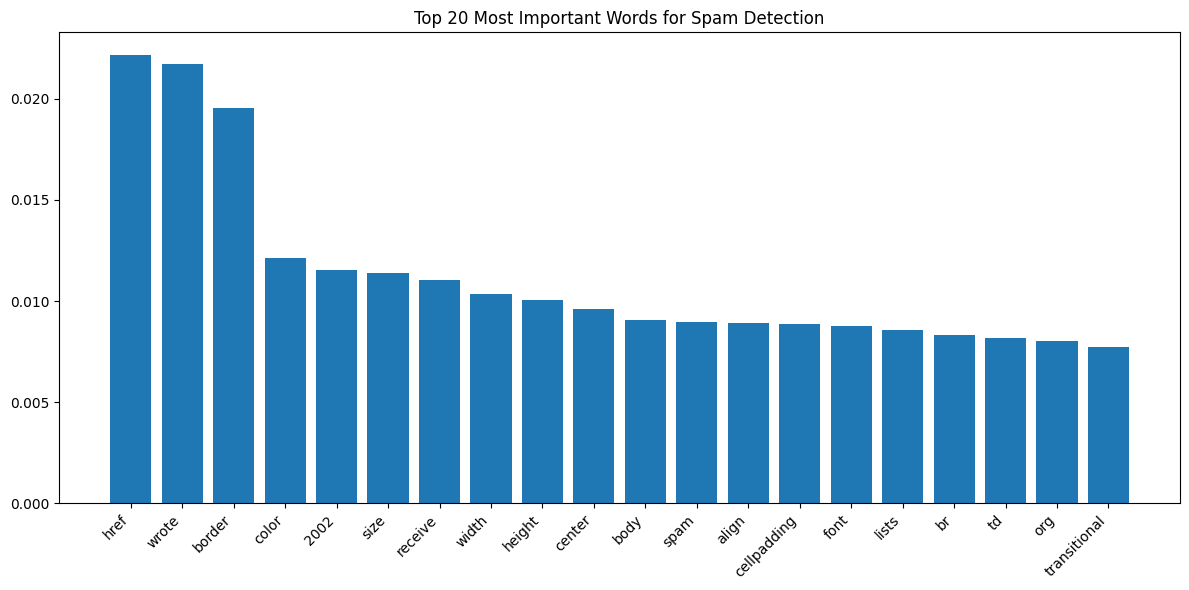

In [66]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances
importances = grid_search_rf.best_estimator_.feature_importances_
feature_names = vectorizer.get_feature_names_out()

# Get top 20 most important words
top_indices = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(12, 6))
plt.bar(range(20), importances[top_indices])
plt.xticks(range(20), feature_names[top_indices], rotation=45, ha='right')
plt.title('Top 20 Most Important Words for Spam Detection')
plt.tight_layout()
plt.show()

In [67]:
# MSPE = mean of squared differences between predicted and actual
mspe = np.mean((y_test - y_pred) ** 2)
print(f"MSPE: {mspe}")

MSPE: 0.03810623556581986


*Classifcation Done*
* When predicting Ham (0) it predicts it right 95% of the time
* When predicting actual spam email, it correctly recalls it correctly 95% of the time
* 98% accuracy when it predicts spam
* Catches 97% of actually spam

**Bagging:**

In [68]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,    # number of trees
    random_state=42,
    n_jobs=-1
)

bagging.fit(X_train_tfidf, y_train)
y_pred_bag = bagging.predict(X_test_tfidf)

print(f"Accuracy: {accuracy_score(y_test, y_pred_bag)}")
print(classification_report(y_test, y_pred_bag))

Accuracy: 0.9734411085450346
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       282
           1       0.98      0.98      0.98       584

    accuracy                           0.97       866
   macro avg       0.97      0.97      0.97       866
weighted avg       0.97      0.97      0.97       866



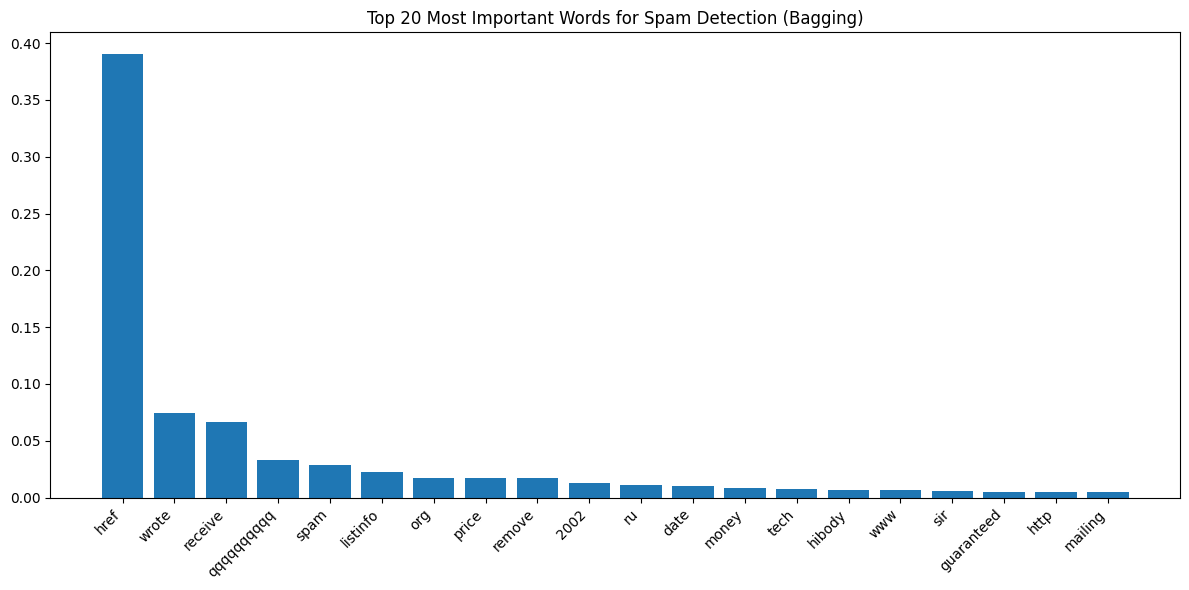

In [69]:
# Get feature importances by averaging across all trees
importances_bag = np.mean([
    tree.feature_importances_ 
    for tree in bagging.estimators_
], axis=0)

top_indices_bag = np.argsort(importances_bag)[::-1][:20]

plt.figure(figsize=(12, 6))
plt.bar(range(20), importances_bag[top_indices_bag])
plt.xticks(range(20), feature_names[top_indices_bag], rotation=45, ha='right')
plt.title('Top 20 Most Important Words for Spam Detection (Bagging)')
plt.tight_layout()
plt.show()

In [72]:
mspe_bag = np.mean((y_test - y_pred_bag) ** 2)
print(f"MSPE Bagging: {mspe_bag}")

MSPE Bagging: 0.026558891454965358


In [78]:
**Random Forest**

SyntaxError: invalid syntax (1373316746.py, line 1)

In [74]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_tfidf, y_train)
y_pred_rf = rf.predict(X_test_tfidf)

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)}")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9745958429561201
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       282
           1       0.98      0.99      0.98       584

    accuracy                           0.97       866
   macro avg       0.97      0.97      0.97       866
weighted avg       0.97      0.97      0.97       866



In [75]:
mspe_dt = np.mean((y_test - y_pred) ** 2)
mspe_bag = np.mean((y_test - y_pred_bag) ** 2)
mspe_rf = np.mean((y_test - y_pred_rf) ** 2)  # from random forest earlier

print(f"MSPE Decision Tree: {mspe_dt:.4f}")
print(f"MSPE Bagging:       {mspe_bag:.4f}")
print(f"MSPE Random Forest: {mspe_rf:.4f}")

MSPE Decision Tree: 0.0381
MSPE Bagging:       0.0266
MSPE Random Forest: 0.0254
